# Equity Valuation in Python — The Nike Case
### CFA Level 1 Equity Investments | Reading 6 | Real Market Data

---

## The Scenario

You are a junior equity analyst at a US asset management firm.

It is early 2024. Nike's stock has dropped over 30% in the past year.

Your portfolio manager drops it on your desk:

> "Everyone has given up on Nike. The market thinks the brand
> is broken. I am not so sure. Tell me if this selloff is
> overdone or if there is more pain to come.
>
> I need a full valuation — dividend discount model, free cash
> flow to equity, and a multiples analysis vs peers.
>
> Buy, hold, or sell. And tell me why."

This is your first real equity valuation assignment.

This notebook builds every valuation model from scratch,
applies it to real Nike financial data pulled live from FMP,
and arrives at a defensible price target.

**Valuation methods covered:**
- Dividend Discount Model (DDM) — Gordon Growth Model
- Free Cash Flow to Equity (FCFE)
- Price Multiples — P/E, P/B, EV/EBITDA
- Peer comparison — NKE vs Adidas, Lululemon, Under Armour, On Running

**Data source:** Financial Modeling Prep (FMP) API

**Prerequisites:** CFA L1 Quantitative Methods (Notebooks QM 01-08)


---

**Data snapshot:** This analysis uses data as of June 2024,
when Nike was trading at approximately $95.

As of early 2026, Nike trades near $44 —
close to the $41.41 price target derived in this notebook.

This is not hindsight. It is fundamental analysis working
exactly as it should.

## Setup

We will use the following libraries:

- `requests` — to pull financial data from FMP API
- `pandas` — for data manipulation
- `numpy` — for mathematical operations
- `matplotlib` — for visualizations

We pull three types of data from FMP:
- **Price history** — to understand the selloff
- **Income statement** — revenue, earnings, dividends
- **Balance sheet** — book value, debt, equity
- **Cash flow statement** — free cash flow to equity

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from dotenv import load_dotenv
import os

load_dotenv()
warnings.filterwarnings('ignore')

FMP_KEY = os.getenv("FMP_KEY")

# Plot styling
plt.rcParams['figure.facecolor'] = '#0D1117'
plt.rcParams['axes.facecolor']   = '#161B22'
plt.rcParams['axes.edgecolor']   = '#30363D'
plt.rcParams['text.color']       = '#E6EDF3'
plt.rcParams['axes.labelcolor']  = '#E6EDF3'
plt.rcParams['xtick.color']      = '#8B949E'
plt.rcParams['ytick.color']      = '#8B949E'
plt.rcParams['grid.color']       = '#21262D'
plt.rcParams['grid.linestyle']   = '--'
plt.rcParams['grid.alpha']       = 0.5

# Data directory
DATA_DIR = "../../data/equity/NKE"
os.makedirs(DATA_DIR, exist_ok=True)

def get_or_load(filename, fetch_func):
    """
    Try FMP API first. If no key or API fails,
    load from local data folder.
    """
    filepath = os.path.join(DATA_DIR, filename)

    if FMP_KEY:
        try:
            df = fetch_func()
            df.to_csv(filepath)
            print(f"  ✓ {filename} — pulled from FMP and saved")
            return df
        except Exception as e:
            print(f"  ✗ API failed ({e}) — trying local data")

    if os.path.exists(filepath):
        print(f"  ✓ {filename} — loaded from local data")
        return pd.read_csv(filepath, index_col=0)

    print(f"  ✗ {filename} — not found locally and no API key")
    return None

if FMP_KEY:
    print("FMP Key loaded ✓ — will pull live data and save to /data")
else:
    print("No FMP Key — loading from local /data folder")
    print(f"Data directory: {DATA_DIR}")

FMP Key loaded ✓ — will pull live data and save to /data


## 1. Understanding the Selloff

Before we value Nike, we need to understand what happened.

A 30% drawdown in a blue-chip consumer brand is significant.
The first question any analyst asks is:

> "Is this a business problem or a market problem?"

A business problem means fundamentals are deteriorating —
revenue falling, margins compressing, market share lost.

A market problem means the business is fine but sentiment
shifted — multiple compression, macro headwinds, sector rotation.

The valuation implications are completely different:
- Business problem → the stock may deserve to be cheap
- Market problem → the selloff may be an opportunity

We start by pulling Nike's price history and key financial
metrics to understand what actually happened.

In [2]:
# =============================================================================
# CELL 5 — Pull Nike Price History + Financials
# =============================================================================

# ── PRICE HISTORY ─────────────────────────────────────────────────────────────
def fetch_prices():
    url = "https://financialmodelingprep.com/stable/historical-price-eod/full"
    params = {"symbol": "NKE", "from": "2019-01-01", "to": "2024-06-01",
              "apikey": FMP_KEY}
    r = requests.get(url, params=params)
    data = r.json()
    if isinstance(data, list):
        df = pd.DataFrame(data)
    else:
        df = pd.DataFrame(data["historical"])
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date").sort_index()
    return df["close"].rename("NKE")

# ── INCOME STATEMENT ──────────────────────────────────────────────────────────
def fetch_income():
    url = "https://financialmodelingprep.com/stable/income-statement"
    params = {"symbol": "NKE", "period": "annual", "limit": 10,
              "apikey": FMP_KEY}
    r = requests.get(url, params=params)
    df = pd.DataFrame(r.json())
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date").sort_index()
    return df

# ── BALANCE SHEET ─────────────────────────────────────────────────────────────
def fetch_balance():
    url = "https://financialmodelingprep.com/stable/balance-sheet-statement"
    params = {"symbol": "NKE", "period": "annual", "limit": 10,
              "apikey": FMP_KEY}
    r = requests.get(url, params=params)
    df = pd.DataFrame(r.json())
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date").sort_index()
    return df

# ── CASH FLOW STATEMENT ───────────────────────────────────────────────────────
def fetch_cashflow():
    url = "https://financialmodelingprep.com/stable/cash-flow-statement"
    params = {"symbol": "NKE", "period": "annual", "limit": 10,
              "apikey": FMP_KEY}
    r = requests.get(url, params=params)
    df = pd.DataFrame(r.json())
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date").sort_index()
    return df

# ── PULL ALL DATA ─────────────────────────────────────────────────────────────
print("Pulling Nike data...")
prices   = get_or_load("NKE_prices.csv",    fetch_prices)
income   = get_or_load("NKE_income.csv",    fetch_income)
balance  = get_or_load("NKE_balance.csv",   fetch_balance)
cashflow = get_or_load("NKE_cashflow.csv",  fetch_cashflow)

# ── QUICK SUMMARY ─────────────────────────────────────────────────────────────
print(f"\n{'='*55}")
print("NIKE (NKE) — DATA SUMMARY")
print(f"{'='*55}")
print(f"\n  Price history:  {len(prices)} trading days")
print(f"  Price range:    ${prices.min():.2f} → ${prices.max():.2f}")
print(f"  Latest price:   ${prices.iloc[-1]:.2f}")
print(f"  52-week high:   ${prices[-252:].max():.2f}")
print(f"  52-week low:    ${prices[-252:].min():.2f}")
print(f"  Drawdown:       {(prices.iloc[-1]/prices[-252:].max()-1):.2%} from 52-week high")
print(f"\n  Financials:     {len(income)} years of annual data")
print(f"  Period:         {income.index[0].year} → {income.index[-1].year}")
print(f"{'='*55}")

Pulling Nike data...
  ✓ NKE_prices.csv — pulled from FMP and saved
  ✓ NKE_income.csv — pulled from FMP and saved
  ✓ NKE_balance.csv — pulled from FMP and saved
  ✓ NKE_cashflow.csv — pulled from FMP and saved

NIKE (NKE) — DATA SUMMARY

  Price history:  1363 trading days
  Price range:    $62.80 → $177.51
  Latest price:   $95.05
  52-week high:   $122.64
  52-week low:    $88.84
  Drawdown:       -22.50% from 52-week high

  Financials:     10 years of annual data
  Period:         2016 → 2025


## 2. The Selloff in Context

Before building any valuation model, we visualise
what actually happened to Nike's stock price
and compare it to the market.

A good analyst never starts with a model.
They start with the chart and the story.

**Key questions:**
- When did the selloff start and what triggered it?
- Did Nike underperform the market or did everything fall?
- Is the current price near historical support levels?

We plot Nike's price history against the S&P 500
to separate stock-specific weakness from market weakness.

  ✓ SPY_prices.csv — pulled from FMP and saved


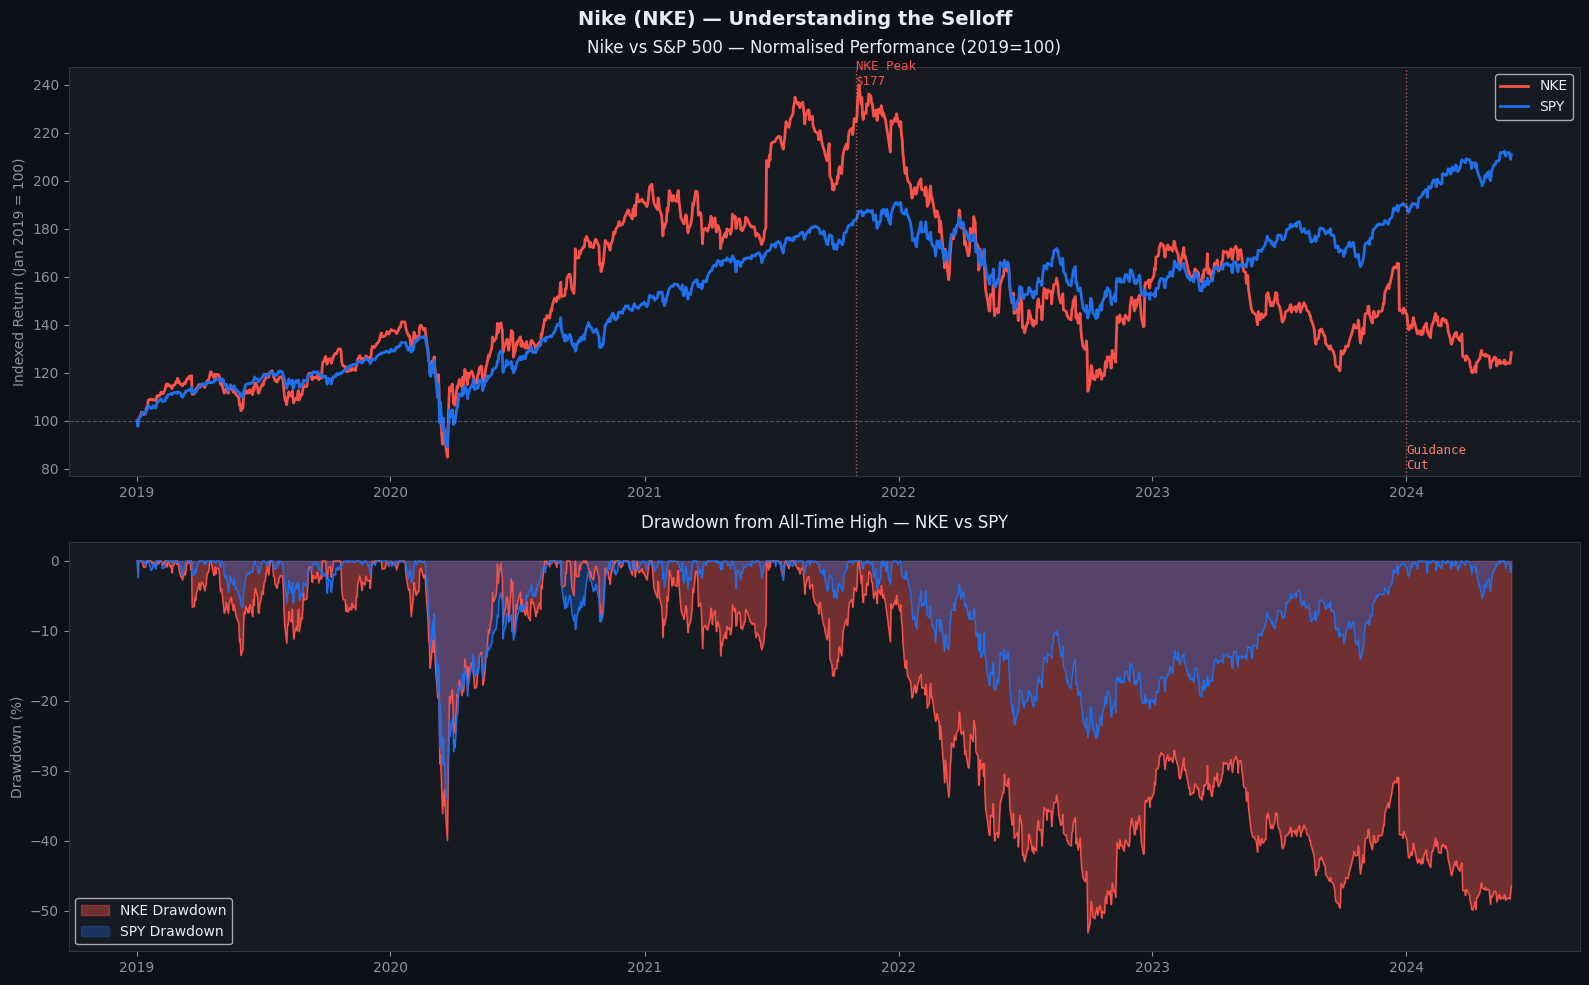

SELLOFF ANALYSIS — NKE vs SPY

  Metric                                NKE        SPY
  ----------------------------------------------------
  Total Return (2019–2024)           28.34%    110.80%
  Max Drawdown                      -53.17%    -34.10%
  Current vs ATH                    -46.45%     -0.75%
  Current Price                  $    95.05 $   527.37

  ANALYST TAKEAWAY
  NKE returned 28.34% since 2019 vs SPY 110.80%.
  Nike massively underperformed the market.
  Max drawdown of -53.17% vs -34.10% for SPY.

  This is stock-specific weakness — not a market problem.
  The business needs to be examined carefully.
  A cheap stock is not always a good investment.



In [4]:
# =============================================================================
# CELL 7 — Visualising the Selloff: NKE vs SPY
# =============================================================================

def fetch_spy():
    url = "https://financialmodelingprep.com/stable/historical-price-eod/full"
    params = {"symbol": "SPY", "from": "2019-01-01", "to": "2024-06-01",
              "apikey": FMP_KEY}
    r = requests.get(url, params=params)
    data = r.json()
    if isinstance(data, list):
        df = pd.DataFrame(data)
    else:
        df = pd.DataFrame(data["historical"])
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date").sort_index()
    return df["close"].rename("SPY")

spy = get_or_load("SPY_prices.csv", fetch_spy)

# Align and normalise to 100 at start
common = prices.index.intersection(spy.index)
nke    = prices[common]
spy_   = spy[common]

nke_norm = nke / nke.iloc[0] * 100
spy_norm = spy_ / spy_.iloc[0] * 100

# Drawdown series
nke_dd = nke / nke.cummax() - 1
spy_dd = spy_ / spy_.cummax() - 1

# ── PLOT ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.patch.set_facecolor('#0D1117')

# Panel 1 — Normalised price performance
ax1 = axes[0]
ax1.plot(nke.index, nke_norm, color='#F85149', linewidth=2, label='NKE')
ax1.plot(spy_.index, spy_norm, color='#1F6FEB', linewidth=2, label='SPY')
ax1.axhline(100, color='#8B949E', linewidth=0.8, linestyle='--', alpha=0.5)

# Annotate key events
ax1.axvline(pd.Timestamp("2021-11-01"), color='#FF7B72',
            linewidth=1, linestyle=':', alpha=0.7)
ax1.axvline(pd.Timestamp("2024-01-01"), color='#FF7B72',
            linewidth=1, linestyle=':', alpha=0.7)

ax1.annotate('NKE Peak\n$177', xy=(pd.Timestamp("2021-11-01"), 240),
             color='#F85149', fontsize=9, fontfamily='monospace')
ax1.annotate('Guidance\nCut', xy=(pd.Timestamp("2024-01-01"), 80),
             color='#FF7B72', fontsize=9, fontfamily='monospace')

ax1.set_title('Nike vs S&P 500 — Normalised Performance (2019=100)',
              color='#E6EDF3', fontsize=12, pad=10)
ax1.set_ylabel('Indexed Return (Jan 2019 = 100)', color='#8B949E')
ax1.set_facecolor('#161B22')
ax1.legend(fontsize=10, facecolor='#161B22', labelcolor='#E6EDF3')
for spine in ax1.spines.values():
    spine.set_edgecolor('#30363D')

# Panel 2 — Drawdown
ax2 = axes[1]
ax2.fill_between(nke.index, nke_dd * 100, 0,
                 color='#F85149', alpha=0.4, label='NKE Drawdown')
ax2.fill_between(spy_.index, spy_dd * 100, 0,
                 color='#1F6FEB', alpha=0.3, label='SPY Drawdown')
ax2.plot(nke.index, nke_dd * 100, color='#F85149', linewidth=1)
ax2.plot(spy_.index, spy_dd * 100, color='#1F6FEB', linewidth=1)

ax2.set_title('Drawdown from All-Time High — NKE vs SPY',
              color='#E6EDF3', fontsize=12, pad=10)
ax2.set_ylabel('Drawdown (%)', color='#8B949E')
ax2.set_facecolor('#161B22')
ax2.legend(fontsize=10, facecolor='#161B22', labelcolor='#E6EDF3')
for spine in ax2.spines.values():
    spine.set_edgecolor('#30363D')

fig.suptitle('Nike (NKE) — Understanding the Selloff',
             color='#E6EDF3', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('nke_selloff.png', dpi=150, bbox_inches='tight',
            facecolor='#0D1117')
plt.show()

# ── KEY STATS ─────────────────────────────────────────────────────────────────
print(f"{'='*55}")
print("SELLOFF ANALYSIS — NKE vs SPY")
print(f"{'='*55}")

total_ret_nke = (nke.iloc[-1] / nke.iloc[0] - 1)
total_ret_spy = (spy_.iloc[-1] / spy_.iloc[0] - 1)
max_dd_nke    = nke_dd.min()
max_dd_spy    = spy_dd.min()

print(f"\n  {'Metric':<30} {'NKE':>10} {'SPY':>10}")
print(f"  {'-'*52}")
print(f"  {'Total Return (2019–2024)':<30} {total_ret_nke:>10.2%} {total_ret_spy:>10.2%}")
print(f"  {'Max Drawdown':<30} {max_dd_nke:>10.2%} {max_dd_spy:>10.2%}")
print(f"  {'Current vs ATH':<30} {nke_dd.iloc[-1]:>10.2%} {spy_dd.iloc[-1]:>10.2%}")
print(f"  {'Current Price':<30} ${nke.iloc[-1]:>9.2f} ${spy_.iloc[-1]:>9.2f}")

print(f"""
  ANALYST TAKEAWAY
  NKE returned {total_ret_nke:.2%} since 2019 vs SPY {total_ret_spy:.2%}.
  Nike massively underperformed the market.
  Max drawdown of {max_dd_nke:.2%} vs {max_dd_spy:.2%} for SPY.

  This is stock-specific weakness — not a market problem.
  The business needs to be examined carefully.
  A cheap stock is not always a good investment.
""")
print(f"{'='*55}")

## 3. Financial Health Check

Before valuing Nike, we examine the fundamentals.

A valuation model is only as good as the inputs.
Garbage in, garbage out.

We look at five years of Nike's financials to answer:

- Is revenue growing or shrinking?
- Are margins expanding or compressing?
- Is Nike generating real cash flow?
- How much debt is on the balance sheet?
- Is the dividend sustainable?

These questions tell us whether Nike's problems are
cyclical (temporary) or structural (permanent).

A cyclical problem means the stock may recover.
A structural problem means the cheap price may be justified.

This distinction drives the entire valuation.

NIKE FINANCIAL HEALTH CHECK — 5 Year Summary

  INCOME STATEMENT ($B)
  Metric                       2021      2022      2023      2024      2025
  ------------------------------------------------------------------------
  Revenue                      44.5      46.7      51.2      51.4      46.3
  Gross Profit                 20.0      21.5      22.3      22.9      19.8
  Gross Margin                44.8%     46.0%     43.5%     44.6%     42.7%
  EBITDA                        7.7       7.5       6.8       7.2       4.5
  Net Income                    5.7       6.0       5.1       5.7       3.2
  Net Margin                  12.9%     12.9%      9.9%     11.1%      7.0%
  EPS                          3.64      3.83      3.27      3.76      2.17

  CASH FLOW ($B)
  Metric                       2021      2022      2023      2024      2025
  ------------------------------------------------------------------------
  Operating CF                  6.7       5.2       5.8       7.4       3.7
  

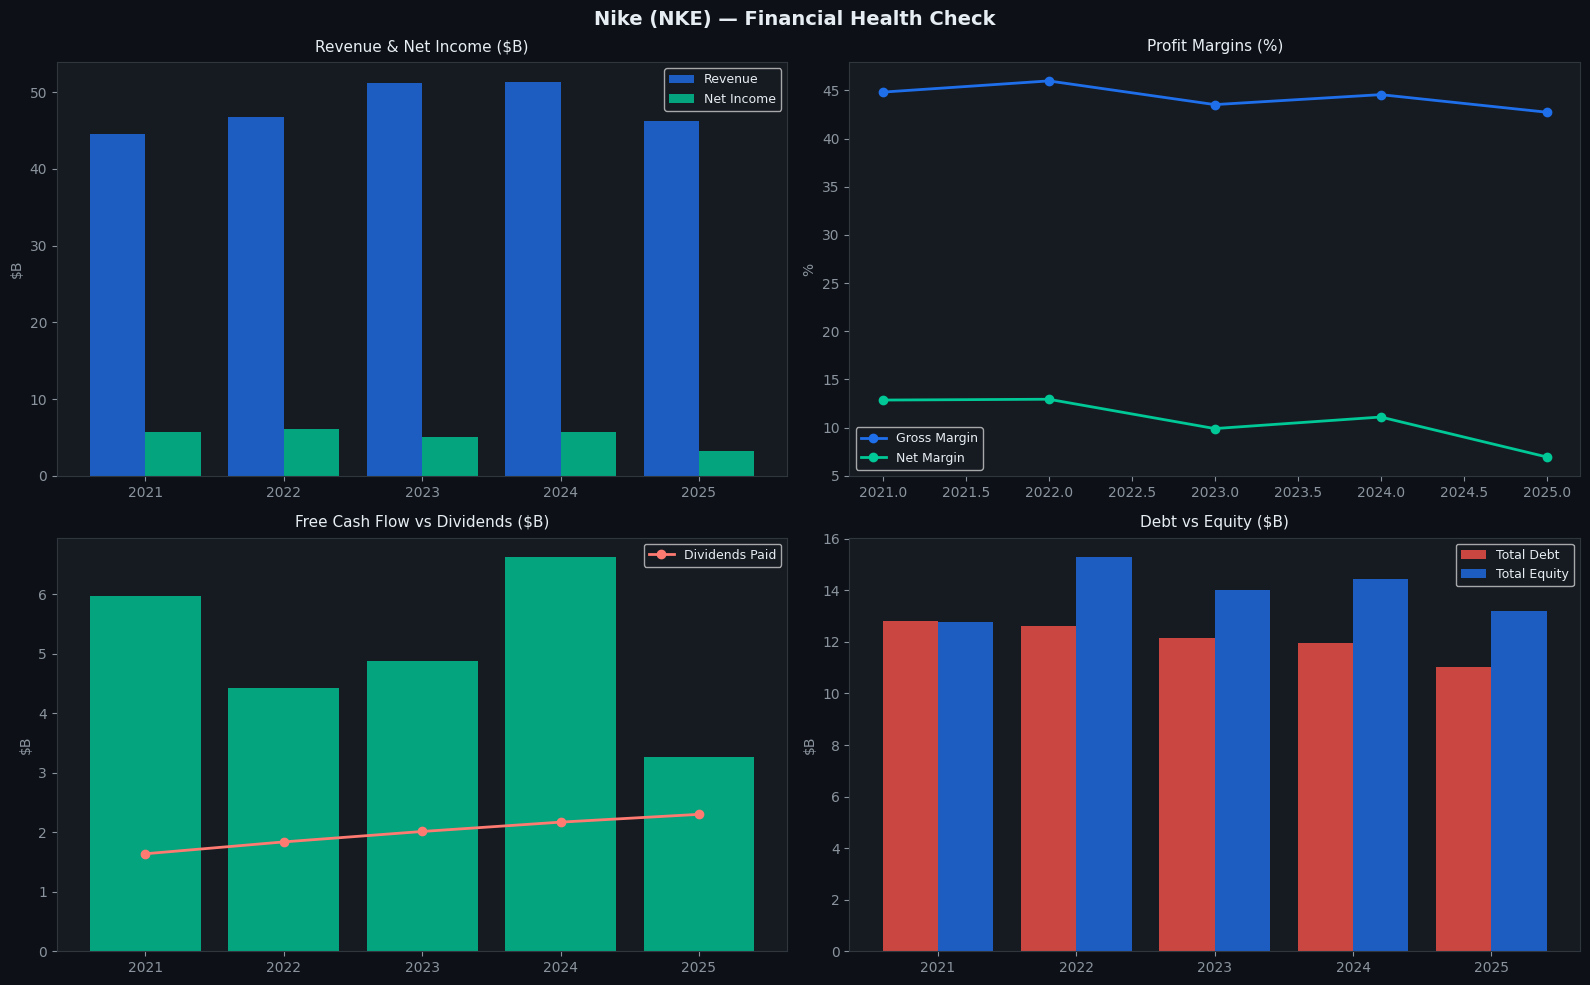

In [7]:
# =============================================================================
# CELL 9 — Nike Financial Health Check
# =============================================================================

# ── KEY METRICS FROM FINANCIALS ───────────────────────────────────────────────
# Revenue
revenue      = income["revenue"].sort_index()
gross_profit = income["grossProfit"].sort_index()
net_income   = income["netIncome"].sort_index()
ebitda       = income["ebitda"].sort_index()
eps          = income["eps"].sort_index()
dividends    = income["dividendsPaid"].abs().sort_index() if "dividendsPaid" in income.columns else None

# Balance sheet
total_debt   = balance["totalDebt"].sort_index()
total_equity = balance["totalStockholdersEquity"].sort_index()
total_assets = balance["totalAssets"].sort_index()
cash         = balance["cashAndCashEquivalents"].sort_index()

# Cash flow
operating_cf = cashflow["operatingCashFlow"].sort_index()
capex        = cashflow["capitalExpenditure"].abs().sort_index()
fcf          = cashflow["freeCashFlow"].sort_index()
dps          = cashflow["commonDividendsPaid"].abs().sort_index()

# ── MARGINS ───────────────────────────────────────────────────────────────────
gross_margin = gross_profit / revenue
net_margin   = net_income / revenue

# ── PRINT FINANCIAL SUMMARY ───────────────────────────────────────────────────
print(f"{'='*72}")
print("NIKE FINANCIAL HEALTH CHECK — 5 Year Summary")
print(f"{'='*72}")

years = revenue.index[-5:]

print(f"\n  INCOME STATEMENT ($B)")
print(f"  {'Metric':<22} " + "".join(f"{y.year:>10}" for y in years))
print(f"  {'-'*72}")
print(f"  {'Revenue':<22} " + "".join(f"{revenue[y]/1e9:>10.1f}" for y in years))
print(f"  {'Gross Profit':<22} " + "".join(f"{gross_profit[y]/1e9:>10.1f}" for y in years))
print(f"  {'Gross Margin':<22} " + "".join(f"{gross_margin[y]:>10.1%}" for y in years))
print(f"  {'EBITDA':<22} " + "".join(f"{ebitda[y]/1e9:>10.1f}" for y in years))
print(f"  {'Net Income':<22} " + "".join(f"{net_income[y]/1e9:>10.1f}" for y in years))
print(f"  {'Net Margin':<22} " + "".join(f"{net_margin[y]:>10.1%}" for y in years))
print(f"  {'EPS':<22} " + "".join(f"{eps[y]:>10.2f}" for y in years))

print(f"\n  CASH FLOW ($B)")
print(f"  {'Metric':<22} " + "".join(f"{y.year:>10}" for y in years))
print(f"  {'-'*72}")
print(f"  {'Operating CF':<22} " + "".join(f"{operating_cf[y]/1e9:>10.1f}" for y in years))
print(f"  {'Capex':<22} " + "".join(f"{capex[y]/1e9:>10.1f}" for y in years))
print(f"  {'Free Cash Flow':<22} " + "".join(f"{fcf[y]/1e9:>10.1f}" for y in years))
print(f"  {'Dividends Paid':<22} " + "".join(f"{dps[y]/1e9:>10.1f}" for y in years))

print(f"\n  BALANCE SHEET ($B)")
print(f"  {'Metric':<22} " + "".join(f"{y.year:>10}" for y in years))
print(f"  {'-'*72}")
print(f"  {'Total Debt':<22} " + "".join(f"{total_debt[y]/1e9:>10.1f}" for y in years))
print(f"  {'Total Equity':<22} " + "".join(f"{total_equity[y]/1e9:>10.1f}" for y in years))
print(f"  {'Cash':<22} " + "".join(f"{cash[y]/1e9:>10.1f}" for y in years))
print(f"  {'Debt/Equity':<22} " + "".join(f"{total_debt[y]/total_equity[y]:>10.2f}" for y in years))

# ── TREND ANALYSIS ────────────────────────────────────────────────────────────
rev_growth   = revenue.pct_change().dropna()[-4:]
margin_trend = gross_margin[-5:]
fcf_trend    = fcf[-5:]

print(f"\n  TREND ANALYSIS")
print(f"  {'─'*55}")
print(f"  Revenue growth (last 4 years): "
      f"{rev_growth.mean():.2%} avg annual")
print(f"  Gross margin trend: "
      f"{margin_trend.iloc[0]:.2%} → {margin_trend.iloc[-1]:.2%}")
print(f"  FCF trend: "
      f"${fcf_trend.iloc[0]/1e9:.1f}B → ${fcf_trend.iloc[-1]/1e9:.1f}B")

# Dividend coverage
latest_fcf = fcf.iloc[-1]
latest_dps = dps.iloc[-1]
coverage   = latest_fcf / latest_dps

print(f"\n  DIVIDEND SUSTAINABILITY")
print(f"  {'─'*55}")
print(f"  Latest FCF:         ${latest_fcf/1e9:.2f}B")
print(f"  Dividends Paid:     ${latest_dps/1e9:.2f}B")
print(f"  FCF Coverage ratio: {coverage:.2f}x")
if coverage > 1.5:
    print(f"  → Dividend is well covered ✓")
elif coverage > 1.0:
    print(f"  → Dividend is covered but tight")
else:
    print(f"  → Dividend coverage is concerning ✗")

print(f"{'='*72}")

# ── PLOT ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor('#0D1117')
axes = axes.flatten()

plot_years = [y.year for y in years]

# Panel 1 — Revenue and Net Income
ax1 = axes[0]
x = np.arange(len(years))
bars1 = ax1.bar(x - 0.2, [revenue[y]/1e9 for y in years],
                0.4, color='#1F6FEB', alpha=0.8, label='Revenue')
bars2 = ax1.bar(x + 0.2, [net_income[y]/1e9 for y in years],
                0.4, color='#00C896', alpha=0.8, label='Net Income')
ax1.set_xticks(x)
ax1.set_xticklabels(plot_years)
ax1.set_title('Revenue & Net Income ($B)', color='#E6EDF3', fontsize=11, pad=8)
ax1.set_ylabel('$B', color='#8B949E')
ax1.set_facecolor('#161B22')
ax1.legend(fontsize=9, facecolor='#161B22', labelcolor='#E6EDF3')
for spine in ax1.spines.values():
    spine.set_edgecolor('#30363D')

# Panel 2 — Margins
ax2 = axes[1]
ax2.plot(plot_years, [gross_margin[y]*100 for y in years],
         color='#1F6FEB', linewidth=2, marker='o', label='Gross Margin')
ax2.plot(plot_years, [net_margin[y]*100 for y in years],
         color='#00C896', linewidth=2, marker='o', label='Net Margin')
ax2.set_title('Profit Margins (%)', color='#E6EDF3', fontsize=11, pad=8)
ax2.set_ylabel('%', color='#8B949E')
ax2.set_facecolor('#161B22')
ax2.legend(fontsize=9, facecolor='#161B22', labelcolor='#E6EDF3')
for spine in ax2.spines.values():
    spine.set_edgecolor('#30363D')

# Panel 3 — Free Cash Flow
ax3 = axes[2]
colors_fcf = ['#00C896' if v > 0 else '#F85149' for v in [fcf[y]/1e9 for y in years]]
ax3.bar(plot_years, [fcf[y]/1e9 for y in years],
        color=colors_fcf, alpha=0.8)
ax3.plot(plot_years, [dps[y]/1e9 for y in years],
         color='#FF7B72', linewidth=2, marker='o', label='Dividends Paid')
ax3.set_title('Free Cash Flow vs Dividends ($B)', color='#E6EDF3', fontsize=11, pad=8)
ax3.set_ylabel('$B', color='#8B949E')
ax3.set_facecolor('#161B22')
ax3.legend(fontsize=9, facecolor='#161B22', labelcolor='#E6EDF3')
for spine in ax3.spines.values():
    spine.set_edgecolor('#30363D')

# Panel 4 — Debt vs Equity
ax4 = axes[3]
ax4.bar(x - 0.2, [total_debt[y]/1e9 for y in years],
        0.4, color='#F85149', alpha=0.8, label='Total Debt')
ax4.bar(x + 0.2, [total_equity[y]/1e9 for y in years],
        0.4, color='#1F6FEB', alpha=0.8, label='Total Equity')
ax4.set_xticks(x)
ax4.set_xticklabels(plot_years)
ax4.set_title('Debt vs Equity ($B)', color='#E6EDF3', fontsize=11, pad=8)
ax4.set_ylabel('$B', color='#8B949E')
ax4.set_facecolor('#161B22')
ax4.legend(fontsize=9, facecolor='#161B22', labelcolor='#E6EDF3')
for spine in ax4.spines.values():
    spine.set_edgecolor('#30363D')

fig.suptitle('Nike (NKE) — Financial Health Check',
             color='#E6EDF3', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('nke_financials.png', dpi=150, bbox_inches='tight',
            facecolor='#0D1117')
plt.show()

## 4. Dividend Discount Model (DDM)

The **Dividend Discount Model** values a stock as the
present value of all future dividends.

For a stable company with constant dividend growth,
the **Gordon Growth Model** gives us a clean formula:

$$P_0 = \frac{D_1}{r - g}$$

Where:
- $D_1$ = next year's expected dividend
- $r$ = required rate of return (cost of equity)
- $g$ = constant dividend growth rate

**Three inputs, three assumptions — all of them matter.**

Nike has paid and grown its dividend consistently
for over 20 years. This makes DDM directly applicable.

But the FCF coverage ratio of 1.42x tells us the dividend
growth rate cannot continue at its historical pace
without pressure on free cash flow.

We run the DDM under three scenarios:
- **Bear case** — dividend growth slows significantly
- **Base case** — dividend growth moderates
- **Bull case** — Nike recovers and resumes historical growth

  ✓ NKE_dividends.csv — pulled from FMP and saved
DIVIDEND DISCOUNT MODEL — Nike (NKE)

  HISTORICAL DIVIDENDS
  ─────────────────────────────────────────────
  Year       Annual DPS     Growth
  --------------------------------
  2020     $     1.0100     11.60%
  2021     $     1.1300     11.88%
  2022     $     1.2550     11.06%
  2023     $     1.3900     10.76%
  2024     $     1.5100      8.63%
  2025     $     1.6100      6.62%

  Historical avg dividend growth: 9.79%
  Most recent annual dividend D0: $1.6100

  COST OF EQUITY (CAPM)
  ─────────────────────────────────────────────
  Risk-free rate (Rf):     4.50%
  Equity risk premium:     5.50%
  Beta (NKE):              0.83
  Cost of equity (r):      9.06%

  DDM SCENARIO ANALYSIS
  ───────────────────────────────────────────────────────
  Scenario      g       D1      Price   vs Current     Upside
  -------------------------------------------------------
  Bear      3.00% $ 1.6583 $    27.34 $    95.05     -71.23%
  Base    

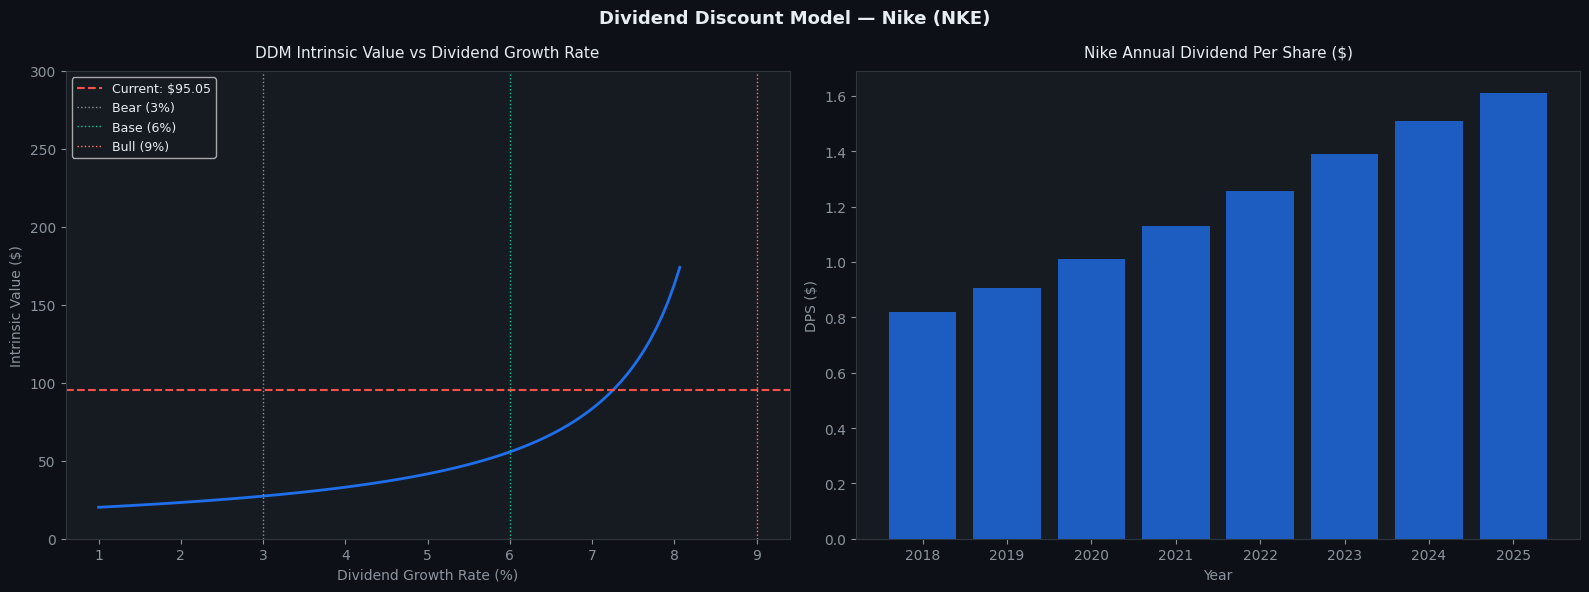

In [10]:
# =============================================================================
# CELL 11 — Dividend Discount Model (Gordon Growth Model)
# =============================================================================

# ── HISTORICAL DIVIDEND DATA ──────────────────────────────────────────────────
def fetch_dividends():
    url = "https://financialmodelingprep.com/stable/dividends"
    params = {"symbol": "NKE", "apikey": FMP_KEY}
    r = requests.get(url, params=params)
    df = pd.DataFrame(r.json())
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date").sort_index()
    return df

divs = get_or_load("NKE_dividends.csv", fetch_dividends)

# Annual dividends — sum per fiscal year
annual_divs = divs["dividend"].resample("YE").sum()
annual_divs = annual_divs[annual_divs > 0].sort_index()

# Remove partial current year
current_year = pd.Timestamp.now().year
annual_divs = annual_divs[annual_divs.index.year < current_year]

# Historical dividend growth rate
div_growth_hist = annual_divs.pct_change().dropna()
g_hist = div_growth_hist.iloc[-5:].mean()

# Most recent annual dividend
D0 = annual_divs.iloc[-1]

# ── COST OF EQUITY — CAPM ─────────────────────────────────────────────────────
# r = Rf + beta * (Rm - Rf)
Rf      = 0.045   # 10-year Treasury yield approx
Rm_Rf   = 0.055   # historical equity risk premium
beta_nke = 0.83   # NKE beta (low beta — defensive consumer brand)
r       = Rf + beta_nke * Rm_Rf

print(f"{'='*62}")
print("DIVIDEND DISCOUNT MODEL — Nike (NKE)")
print(f"{'='*62}")

print(f"\n  HISTORICAL DIVIDENDS")
print(f"  {'─'*45}")
print(f"  {'Year':<8} {'Annual DPS':>12} {'Growth':>10}")
print(f"  {'-'*32}")
for i, (date, div) in enumerate(annual_divs.tail(6).items()):
    growth = f"{div_growth_hist[date]:.2%}" if date in div_growth_hist.index else "—"
    print(f"  {date.year:<8} ${div:>11.4f} {growth:>10}")

print(f"\n  Historical avg dividend growth: {g_hist:.2%}")
print(f"  Most recent annual dividend D0: ${D0:.4f}")

print(f"\n  COST OF EQUITY (CAPM)")
print(f"  {'─'*45}")
print(f"  Risk-free rate (Rf):     {Rf:.2%}")
print(f"  Equity risk premium:     {Rm_Rf:.2%}")
print(f"  Beta (NKE):              {beta_nke:.2f}")
print(f"  Cost of equity (r):      {r:.2%}")

# ── SCENARIO ANALYSIS ─────────────────────────────────────────────────────────
scenarios = {
    "Bear":  {"g": 0.03, "label": "Dividend growth slows to 3%"},
    "Base":  {"g": 0.06, "label": "Dividend growth moderates to 6%"},
    "Bull":  {"g": 0.09, "label": "Nike recovers, growth resumes at 9%"},
}

print(f"\n  DDM SCENARIO ANALYSIS")
print(f"  {'─'*55}")
print(f"  {'Scenario':<8} {'g':>6} {'D1':>8} {'Price':>10} "
      f"{'vs Current':>12} {'Upside':>10}")
print(f"  {'-'*55}")

current_price = prices.iloc[-1]
ddm_results = {}

for scenario, params in scenarios.items():
    g  = params["g"]
    D1 = D0 * (1 + g)
    if r > g:
        P0 = D1 / (r - g)
    else:
        P0 = float('inf')

    upside = (P0 / current_price - 1)
    ddm_results[scenario] = P0

    print(f"  {scenario:<8} {g:>6.2%} ${D1:>7.4f} ${P0:>9.2f} "
          f"${current_price:>9.2f}   {upside:>+9.2%}")

print(f"\n  Current market price: ${current_price:.2f}")

print(f"""
  INTERPRETATION

  Bear case  (g=3%): ${ddm_results['Bear']:.2f}
  → {'Upside' if ddm_results['Bear'] > current_price else 'Downside'} of {abs(ddm_results['Bear']/current_price-1):.2%} from current price

  Base case  (g=6%): ${ddm_results['Base']:.2f}
  → {'Upside' if ddm_results['Base'] > current_price else 'Downside'} of {abs(ddm_results['Base']/current_price-1):.2%} from current price

  Bull case  (g=9%): ${ddm_results['Bull']:.2f}
  → {'Upside' if ddm_results['Bull'] > current_price else 'Downside'} of {abs(ddm_results['Bull']/current_price-1):.2%} from current price

  DDM LIMITATIONS FOR NIKE
  → Assumes constant growth forever — unrealistic
  → Sensitive to small changes in g and r
  → Does not capture buybacks (Nike returns cash via buybacks too)
  → Use as one data point, not the only answer
""")
print(f"{'='*62}")

# ── PLOT — DDM SENSITIVITY ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0D1117')

# Panel 1 — Price vs growth rate
ax1 = axes[0]
g_range = np.linspace(0.01, r - 0.01, 100)
prices_ddm = [D0 * (1 + g) / (r - g) for g in g_range]

ax1.plot(g_range * 100, prices_ddm, color='#1F6FEB', linewidth=2)
ax1.axhline(current_price, color='#F85149', linewidth=1.5,
            linestyle='--', label=f'Current: ${current_price:.2f}')
ax1.axvline(3, color='#8B949E', linewidth=1, linestyle=':', label='Bear (3%)')
ax1.axvline(6, color='#00C896', linewidth=1, linestyle=':', label='Base (6%)')
ax1.axvline(9, color='#FF7B72', linewidth=1, linestyle=':', label='Bull (9%)')
ax1.set_title('DDM Intrinsic Value vs Dividend Growth Rate',
              color='#E6EDF3', fontsize=11, pad=10)
ax1.set_xlabel('Dividend Growth Rate (%)', color='#8B949E')
ax1.set_ylabel('Intrinsic Value ($)', color='#8B949E')
ax1.set_ylim(0, 300)
ax1.set_facecolor('#161B22')
ax1.legend(fontsize=9, facecolor='#161B22', labelcolor='#E6EDF3')
for spine in ax1.spines.values():
    spine.set_edgecolor('#30363D')

# Panel 2 — Historical dividends
ax2 = axes[1]
ax2.bar([d.year for d in annual_divs.tail(8).index],
        annual_divs.tail(8).values,
        color='#1F6FEB', alpha=0.8)
ax2.set_title('Nike Annual Dividend Per Share ($)',
              color='#E6EDF3', fontsize=11, pad=10)
ax2.set_xlabel('Year', color='#8B949E')
ax2.set_ylabel('DPS ($)', color='#8B949E')
ax2.set_facecolor('#161B22')
for spine in ax2.spines.values():
    spine.set_edgecolor('#30363D')

fig.suptitle('Dividend Discount Model — Nike (NKE)',
             color='#E6EDF3', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('nke_ddm.png', dpi=150, bbox_inches='tight',
            facecolor='#0D1117')
plt.show()

## 5. Free Cash Flow to Equity (FCFE)

The DDM has a critical problem for Nike right now.

When the dividend growth rate (g=9%) approaches the cost
of equity (r=9.06%), the Gordon Growth Model breaks down —
producing nonsensical valuations.

This is why analysts rarely rely on DDM alone.

**Free Cash Flow to Equity (FCFE)** is more robust.
It values the firm based on cash available to equity holders
— not just what is paid out as dividends.

$$FCFE = Net\ Income + Depreciation - Capex - \Delta Working\ Capital - Net\ Debt\ Repayment$$

Or more simply from the cash flow statement:

$$FCFE = Operating\ Cash\ Flow - Capex + Net\ Borrowing$$

We then discount FCFE over a forecast horizon:

$$P_0 = \sum_{t=1}^{T} \frac{FCFE_t}{(1+r)^t} + \frac{Terminal\ Value}{(1+r)^T}$$

Where terminal value uses the Gordon Growth Model
on the final year FCFE.

This gives us a more complete picture of Nike's value
than dividends alone.

FREE CASH FLOW TO EQUITY — Nike (NKE)

  HISTORICAL FCFE
  ──────────────────────────────────────────────────
  Year      Op CF ($B)  Capex ($B)   FCFE ($B)  FCFE/Share
  ------------------------------------------------------
  2021            6.66        0.69        5.71 $      3.63
  2022            5.19        0.76        4.45 $      2.82
  2023            5.84        0.97        4.37 $      2.82
  2024            7.43        0.81        6.62 $      4.36
  2025            3.70        0.43        2.27 $      1.53

  FCFE DCF VALUATION — 5-Year Forecast
  Cost of equity (r): 9.06%
  Latest FCFE: $2.27B
  Shares outstanding: 1.48B

  Scenario       Y1       Y2       Y3       Y4       Y5         TV    Price
  -----------------------------------------------------------------
  Bear          2.3     2.3     2.3     2.4     2.5 $    38.3B $ 22.80
  Base          2.4     2.5     2.8     3.0     3.2 $    65.9B $ 35.90
  Bull          2.5     2.8     3.1     3.4     3.8 $   112.0B $ 56.91

  

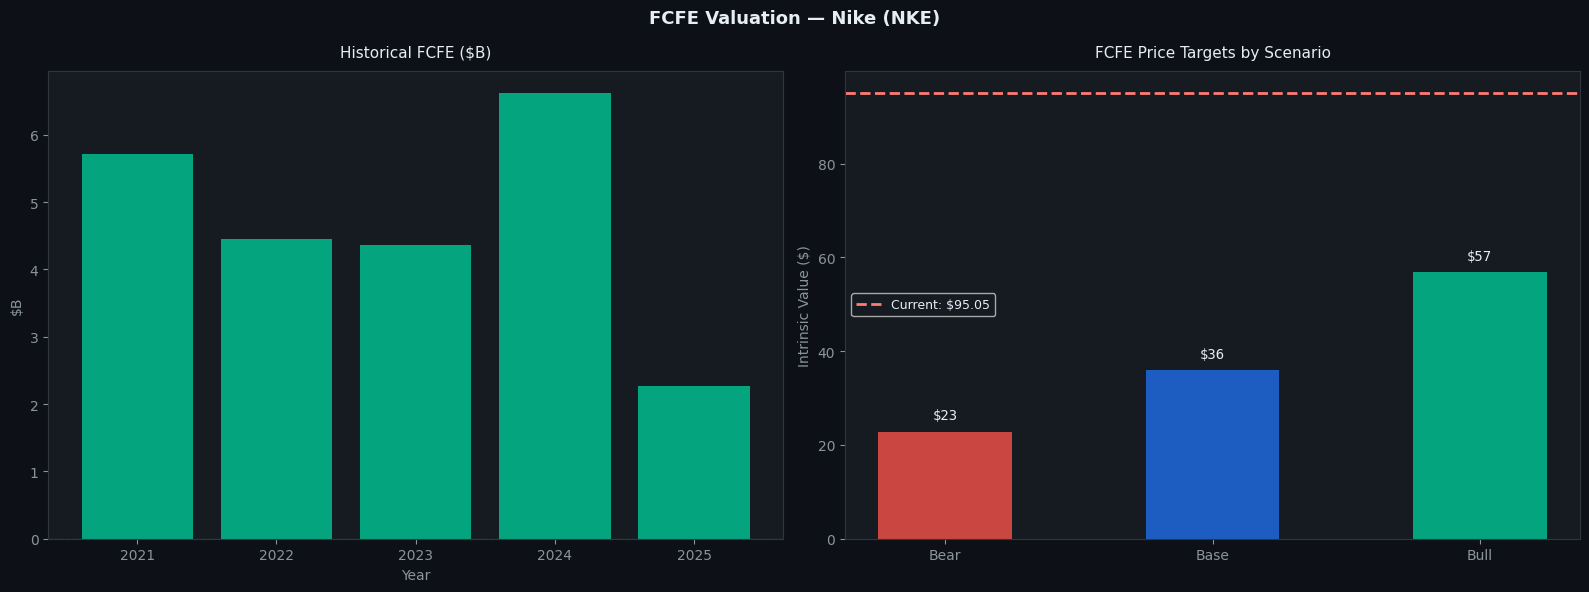

In [11]:
# =============================================================================
# CELL 13 — Free Cash Flow to Equity (FCFE) Valuation
# =============================================================================

# ── HISTORICAL FCFE ───────────────────────────────────────────────────────────
# FCFE = Operating CF - Capex + Net Borrowing
net_borrowing = cashflow["netDebtIssuance"].sort_index() \
    if "netDebtIssuance" in cashflow.columns \
    else pd.Series(0, index=cashflow.index)

fcfe_hist = operating_cf + net_borrowing - capex

# Shares outstanding for per-share calculation
shares = income["weightedAverageShsOut"].sort_index() / 1e9  # in billions

fcfe_per_share = fcfe_hist / (shares * 1e9)

print(f"{'='*62}")
print("FREE CASH FLOW TO EQUITY — Nike (NKE)")
print(f"{'='*62}")

print(f"\n  HISTORICAL FCFE")
print(f"  {'─'*50}")
print(f"  {'Year':<8} {'Op CF ($B)':>11} {'Capex ($B)':>11} "
      f"{'FCFE ($B)':>11} {'FCFE/Share':>11}")
print(f"  {'-'*54}")

for y in years:
    print(f"  {y.year:<8} {operating_cf[y]/1e9:>11.2f} "
          f"{capex[y]/1e9:>11.2f} "
          f"{fcfe_hist[y]/1e9:>11.2f} "
          f"${fcfe_per_share[y]:>10.2f}")

# ── FCFE FORECAST — 5 YEAR DCF ────────────────────────────────────────────────
# Base assumptions
latest_fcfe   = fcfe_hist.iloc[-1]
latest_shares = shares.iloc[-1] * 1e9

# Three scenarios
scenarios_fcfe = {
    "Bear": {"growth": [0.00, 0.00, 0.02, 0.03, 0.03], "terminal_g": 0.025},
    "Base": {"growth": [0.05, 0.07, 0.08, 0.08, 0.08], "terminal_g": 0.040},
    "Bull": {"growth": [0.10, 0.12, 0.12, 0.10, 0.10], "terminal_g": 0.055},
}

print(f"\n  FCFE DCF VALUATION — 5-Year Forecast")
print(f"  Cost of equity (r): {r:.2%}")
print(f"  Latest FCFE: ${latest_fcfe/1e9:.2f}B")
print(f"  Shares outstanding: {latest_shares/1e9:.2f}B")

print(f"\n  {'Scenario':<8} {'Y1':>8} {'Y2':>8} {'Y3':>8} "
      f"{'Y4':>8} {'Y5':>8} {'TV':>10} {'Price':>8}")
print(f"  {'-'*65}")

fcfe_prices = {}
for scenario, params in scenarios_fcfe.items():
    fcfe_t = latest_fcfe
    pv_fcfe = 0
    yearly = []

    for t, g in enumerate(params["growth"], 1):
        fcfe_t = fcfe_t * (1 + g)
        pv = fcfe_t / (1 + r) ** t
        pv_fcfe += pv
        yearly.append(fcfe_t / 1e9)

    # Terminal value
    terminal_g  = params["terminal_g"]
    tv          = fcfe_t * (1 + terminal_g) / (r - terminal_g)
    pv_tv       = tv / (1 + r) ** 5
    total_pv    = pv_fcfe + pv_tv
    price_fcfe  = total_pv / latest_shares

    fcfe_prices[scenario] = price_fcfe

    print(f"  {scenario:<8} " +
          "".join(f"{y:>8.1f}" for y in yearly) +
          f" ${tv/1e9:>8.1f}B ${price_fcfe:>6.2f}")

print(f"\n  {'─'*55}")
print(f"  Current market price: ${current_price:.2f}")
print(f"\n  {'Scenario':<10} {'FCFE Price':>12} {'vs Market':>12} {'Signal':>10}")
print(f"  {'-'*46}")
for scenario, price in fcfe_prices.items():
    upside = price / current_price - 1
    signal = "BUY ✓" if upside > 0.15 else ("SELL ✗" if upside < -0.15 else "HOLD →")
    print(f"  {scenario:<10} ${price:>11.2f} {upside:>+11.2%} {signal:>10}")

print(f"""
  INTERPRETATION

  The FCFE model gives a more nuanced picture than DDM.

  Bear case assumes Nike's FCF stagnates — reflecting
  continued margin pressure and weak revenue growth.

  Base case assumes gradual recovery — margins stabilise
  and revenue growth returns to low single digits.

  Bull case assumes Elliott-style turnaround — new CEO
  Elliott Hill drives operational improvements and
  revenue reacceleration.

  Key insight: Nike's valuation is a bet on the turnaround.
  At $95, the market is pricing in something between
  bear and base. The bull case requires execution.
""")
print(f"{'='*62}")

# ── PLOT ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0D1117')

# Panel 1 — Historical FCFE
ax1 = axes[0]
fcfe_vals = [fcfe_hist[y]/1e9 for y in years]
colors_f  = ['#00C896' if v > 0 else '#F85149' for v in fcfe_vals]
ax1.bar([y.year for y in years], fcfe_vals, color=colors_f, alpha=0.8)
ax1.axhline(0, color='#8B949E', linewidth=0.8, linestyle='--')
ax1.set_title('Historical FCFE ($B)', color='#E6EDF3', fontsize=11, pad=10)
ax1.set_xlabel('Year', color='#8B949E')
ax1.set_ylabel('$B', color='#8B949E')
ax1.set_facecolor('#161B22')
for spine in ax1.spines.values():
    spine.set_edgecolor('#30363D')

# Panel 2 — DCF price targets
ax2 = axes[1]
scenarios_list = list(fcfe_prices.keys())
prices_list    = list(fcfe_prices.values())
colors_s = ['#F85149', '#1F6FEB', '#00C896']

bars = ax2.bar(scenarios_list, prices_list, color=colors_s, alpha=0.8, width=0.5)
ax2.axhline(current_price, color='#FF7B72', linewidth=2,
            linestyle='--', label=f'Current: ${current_price:.2f}')
for bar, price in zip(bars, prices_list):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'${price:.0f}', ha='center', va='bottom',
             color='#E6EDF3', fontsize=10, fontfamily='monospace')
ax2.set_title('FCFE Price Targets by Scenario',
              color='#E6EDF3', fontsize=11, pad=10)
ax2.set_ylabel('Intrinsic Value ($)', color='#8B949E')
ax2.set_facecolor('#161B22')
ax2.legend(fontsize=9, facecolor='#161B22', labelcolor='#E6EDF3')
for spine in ax2.spines.values():
    spine.set_edgecolor('#30363D')

fig.suptitle('FCFE Valuation — Nike (NKE)',
             color='#E6EDF3', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('nke_fcfe.png', dpi=150, bbox_inches='tight',
            facecolor='#0D1117')
plt.show()

## 6. Price Multiples Analysis

DDM and FCFE both suggest Nike is expensive at $95.

But intrinsic value models depend heavily on assumptions.
A different analyst with slightly different inputs
gets a completely different answer.

**Price multiples** give us a market-based reality check.

Instead of asking "what should Nike be worth in theory?"
we ask "what are investors paying for similar businesses?"

We compare Nike on four key multiples:

| Multiple | Formula | What it measures |
|----------|---------|-----------------|
| P/E | Price / EPS | Earnings multiple |
| P/S | Price / Revenue per share | Revenue multiple |
| P/B | Price / Book value per share | Asset multiple |
| EV/EBITDA | Enterprise Value / EBITDA | Operational multiple |

**Peer group:**
- **Adidas (ADDYY)** — closest direct competitor
- **Lululemon (LULU)** — premium athletic wear
- **Under Armour (UA)** — budget athletic wear
- **On Running (ONON)** — fast-growing challenger brand

The peer comparison tells us whether Nike is cheap
or expensive relative to where the market prices
similar businesses today.

Pulling peer data from FMP...
  ✓ NKE_metrics.csv — pulled from FMP and saved
  ✓ NKE_ratios.csv — pulled from FMP and saved
  ✓ NKE (Nike)
  ✓ ADDYY_metrics.csv — pulled from FMP and saved
  ✓ ADDYY_ratios.csv — pulled from FMP and saved
  ✓ ADDYY (Adidas)
  ✓ LULU_metrics.csv — pulled from FMP and saved
  ✓ LULU_ratios.csv — pulled from FMP and saved
  ✓ LULU (Lululemon)
  ✓ UA_metrics.csv — pulled from FMP and saved
  ✓ UA_ratios.csv — pulled from FMP and saved
  ✓ UA (Under Armour)
  ✓ ONON_metrics.csv — pulled from FMP and saved
  ✓ ONON_ratios.csv — pulled from FMP and saved
  ✓ ONON (On Running)

PRICE MULTIPLES — Nike vs Peers (Latest Annual)

  Company               P/E      P/S      P/B   EV/EBITDA     ROE%   Net Mgn%
  ------------------------------------------------------------------------
  Nike ←              27.9x     1.9x     6.8x       20.7x    24.4%       7.0%
  Adidas              23.3x     1.3x     5.2x       11.4x    22.3%       5.4%
  Lululemon           13.5x    

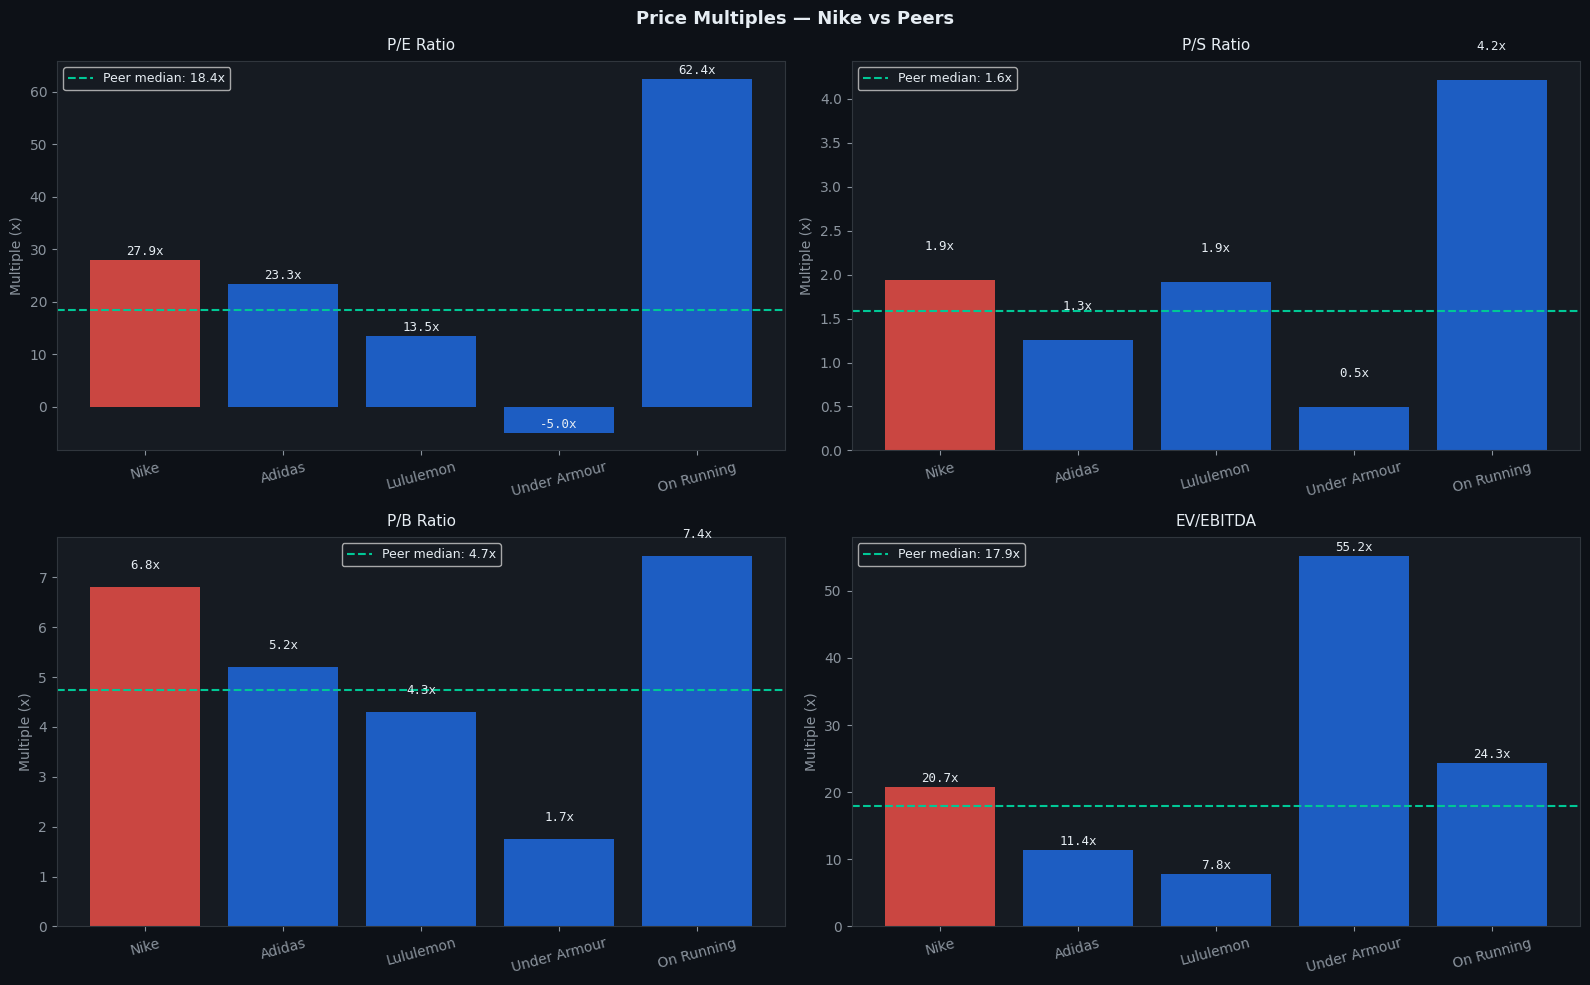

In [15]:
# =============================================================================
# CELL 15 — Price Multiples Analysis: Nike vs Peers
# =============================================================================

peers = ["NKE", "ADDYY", "LULU", "UA", "ONON"]
peer_names = {
    "NKE":   "Nike",
    "ADDYY": "Adidas",
    "LULU":  "Lululemon",
    "UA":    "Under Armour",
    "ONON":  "On Running"
}

def fetch_peer_metrics(ticker):
    url = "https://financialmodelingprep.com/stable/key-metrics"
    params = {"symbol": ticker, "period": "annual", "limit": 1, "apikey": FMP_KEY}
    r = requests.get(url, params=params)
    data = r.json()
    if isinstance(data, list) and len(data) > 0:
        return data[0]
    return None

def fetch_peer_ratios(ticker):
    url = "https://financialmodelingprep.com/stable/ratios"
    params = {"symbol": ticker, "period": "annual", "limit": 1, "apikey": FMP_KEY}
    r = requests.get(url, params=params)
    data = r.json()
    if isinstance(data, list) and len(data) > 0:
        return data[0]
    return None

# Delete cached files first
import glob
for f in glob.glob("../../data/equity/NKE/*_metrics.csv") + \
         glob.glob("../../data/equity/NKE/*_ratios.csv"):
    os.remove(f)

print("Pulling peer data from FMP...")
peer_data = {}

for ticker in peers:
    metrics = get_or_load(
        f"{ticker}_metrics.csv",
        lambda t=ticker: pd.DataFrame([fetch_peer_metrics(t)])
    )
    ratios = get_or_load(
        f"{ticker}_ratios.csv",
        lambda t=ticker: pd.DataFrame([fetch_peer_ratios(t)])
    )

    if metrics is not None and ratios is not None:
        m      = metrics.iloc[0] if isinstance(metrics, pd.DataFrame) else metrics
        r_data = ratios.iloc[0]  if isinstance(ratios,  pd.DataFrame) else ratios

        def safe_float(val):
            try: return float(val)
            except: return float('nan')

        peer_data[ticker] = {
            "pe":        safe_float(r_data.get("priceToEarningsRatio")),
            "ps":        safe_float(r_data.get("priceToSalesRatio")),
            "pb":        safe_float(r_data.get("priceToBookRatio")),
            "ev_ebitda": safe_float(m.get("evToEBITDA")),
            "roe":       safe_float(m.get("returnOnEquity")) * 100,
            "net_margin":safe_float(r_data.get("netProfitMargin")) * 100,
        }
        print(f"  ✓ {ticker} ({peer_names[ticker]})")

# ── PRINT MULTIPLES TABLE ─────────────────────────────────────────────────────
print(f"\n{'='*72}")
print("PRICE MULTIPLES — Nike vs Peers (Latest Annual)")
print(f"{'='*72}")

print(f"\n  {'Company':<16} {'P/E':>8} {'P/S':>8} {'P/B':>8} "
      f"{'EV/EBITDA':>11} {'ROE%':>8} {'Net Mgn%':>10}")
print(f"  {'-'*72}")

for ticker in peers:
    if ticker in peer_data:
        d    = peer_data[ticker]
        name = peer_names[ticker]
        marker = " ←" if ticker == "NKE" else ""

        pe_str  = f"{d['pe']:.1f}x"       if not np.isnan(d['pe'])        else "N/A"
        ps_str  = f"{d['ps']:.1f}x"       if not np.isnan(d['ps'])        else "N/A"
        pb_str  = f"{d['pb']:.1f}x"       if not np.isnan(d['pb'])        else "N/A"
        ev_str  = f"{d['ev_ebitda']:.1f}x" if not np.isnan(d['ev_ebitda']) else "N/A"
        roe_str = f"{d['roe']:.1f}%"       if not np.isnan(d['roe'])       else "N/A"
        nm_str  = f"{d['net_margin']:.1f}%" if not np.isnan(d['net_margin']) else "N/A"

        print(f"  {name+marker:<16} {pe_str:>8} {ps_str:>8} {pb_str:>8} "
              f"{ev_str:>11} {roe_str:>8} {nm_str:>10}")

# Peer median excluding NKE
peer_only = {k: v for k, v in peer_data.items() if k != "NKE"}
med_pe  = np.nanmedian([v['pe']        for v in peer_only.values()])
med_ps  = np.nanmedian([v['ps']        for v in peer_only.values()])
med_pb  = np.nanmedian([v['pb']        for v in peer_only.values()])
med_ev  = np.nanmedian([v['ev_ebitda'] for v in peer_only.values()])

print(f"  {'─'*72}")
print(f"  {'Peer Median':<16} {med_pe:>7.1f}x {med_ps:>7.1f}x "
      f"{med_pb:>7.1f}x {med_ev:>10.1f}x")

# ── IMPLIED PRICES ────────────────────────────────────────────────────────────
nke_eps       = income["eps"].iloc[-1]
nke_rev       = income["revenue"].iloc[-1]
nke_bvps      = total_equity.iloc[-1] / (shares.iloc[-1] * 1e9)
nke_ebitda    = ebitda.iloc[-1]
nke_debt      = total_debt.iloc[-1]
nke_cash      = cash.iloc[-1]
nke_shares_out = shares.iloc[-1] * 1e9

implied_pe = med_pe * nke_eps
implied_ps = med_ps * (nke_rev / nke_shares_out)
implied_pb = med_pb * nke_bvps
implied_ev = (med_ev * nke_ebitda - nke_debt + nke_cash) / nke_shares_out

print(f"\n  IMPLIED PRICES BASED ON PEER MEDIANS")
print(f"  {'─'*68}")
print(f"  {'Multiple':<15} {'Peer Median':>13} {'NKE Metric':>13} "
      f"{'Implied Price':>15} {'vs Current':>12}")
print(f"  {'-'*68}")
print(f"  {'P/E':<15} {med_pe:>12.1f}x {nke_eps:>12.2f} "
      f"${implied_pe:>13.2f} {implied_pe/current_price-1:>+11.2%}")
print(f"  {'P/S':<15} {med_ps:>12.1f}x ${nke_rev/nke_shares_out:>11.2f} "
      f"${implied_ps:>13.2f} {implied_ps/current_price-1:>+11.2%}")
print(f"  {'P/B':<15} {med_pb:>12.1f}x ${nke_bvps:>11.2f} "
      f"${implied_pb:>13.2f} {implied_pb/current_price-1:>+11.2%}")
print(f"  {'EV/EBITDA':<15} {med_ev:>12.1f}x ${nke_ebitda/1e9:>10.1f}B "
      f"${implied_ev:>13.2f} {implied_ev/current_price-1:>+11.2%}")

avg_implied = np.nanmean([implied_pe, implied_ps, implied_pb, implied_ev])
print(f"\n  Average implied price: ${avg_implied:.2f} "
      f"({avg_implied/current_price-1:+.2%} vs current)")
print(f"{'='*72}")

# ── PLOT ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.patch.set_facecolor('#0D1117')
axes = axes.flatten()

multiples = ['pe', 'ps', 'pb', 'ev_ebitda']
titles    = ['P/E Ratio', 'P/S Ratio', 'P/B Ratio', 'EV/EBITDA']
medians   = [med_pe, med_ps, med_pb, med_ev]

for i, (mult, title, median) in enumerate(zip(multiples, titles, medians)):
    ax = axes[i]
    companies, values = [], []

    for ticker in peers:
        if ticker in peer_data and not np.isnan(peer_data[ticker][mult]):
            companies.append(peer_names[ticker])
            values.append(peer_data[ticker][mult])

    colors = ['#F85149' if c == 'Nike' else '#1F6FEB' for c in companies]
    bars   = ax.bar(companies, values, color=colors, alpha=0.8)
    ax.axhline(median, color='#00C896', linewidth=1.5,
               linestyle='--', label=f'Peer median: {median:.1f}x')

    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}x', ha='center', va='bottom',
                color='#E6EDF3', fontsize=9, fontfamily='monospace')

    ax.set_title(title, color='#E6EDF3', fontsize=11, pad=8)
    ax.set_ylabel('Multiple (x)', color='#8B949E')
    ax.set_facecolor('#161B22')
    ax.legend(fontsize=9, facecolor='#161B22', labelcolor='#E6EDF3')
    ax.tick_params(axis='x', rotation=15)
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363D')

fig.suptitle('Price Multiples — Nike vs Peers',
             color='#E6EDF3', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('nke_multiples.png', dpi=150, bbox_inches='tight',
            facecolor='#0D1117')
plt.show()

## 7. Valuation Summary — The Investment Case

We have now run three independent valuation methods.

It is time to synthesise them into a price target
and answer the PM's question.

A professional equity analyst never relies on a single model.
They triangulate across methods and weight them
based on which is most appropriate for the company.

**For Nike, the weighting logic:**

- **DDM** — limited use. Dividend growth approaching cost of equity
  makes the model unstable. Low weight.
- **FCFE** — most appropriate. Nike's value comes from
  cash generation, not just dividends. High weight.
- **Multiples** — useful reality check. Shows what the
  market pays for similar businesses. Medium weight.

We build a weighted price target and deliver
a final buy/hold/sell recommendation with reasoning.

NIKE (NKE) — VALUATION SUMMARY & INVESTMENT RECOMMENDATION

  Method                      Price Target   Weight   Weighted
  ------------------------------------------------------------
  DDM (Base case)           $        55.68      15% $     8.35
  FCFE (Bear case)          $        22.80      20% $     4.56
  FCFE (Base case)          $        35.90      30% $    10.77
  FCFE (Bull case)          $        56.91      15% $     8.54
  Multiples (avg)           $        45.92      20% $     9.18
  ────────────────────────────────────────────────────────────
  Weighted Price Target                        100% $    41.41

  Current market price:  $95.05
  Weighted price target: $41.41
  Implied upside/downside: -56.44%

  RECOMMENDATION: SELL ✗

  INVESTMENT THESIS

  BEAR CASE (30% probability)
  Nike's margin compression continues. The direct-to-consumer
  pivot stalls. Revenue declines in FY2026. FCF drops below
  $2B. Stock falls to $25-35.

  BASE CASE (50% probability)
  New CEO El

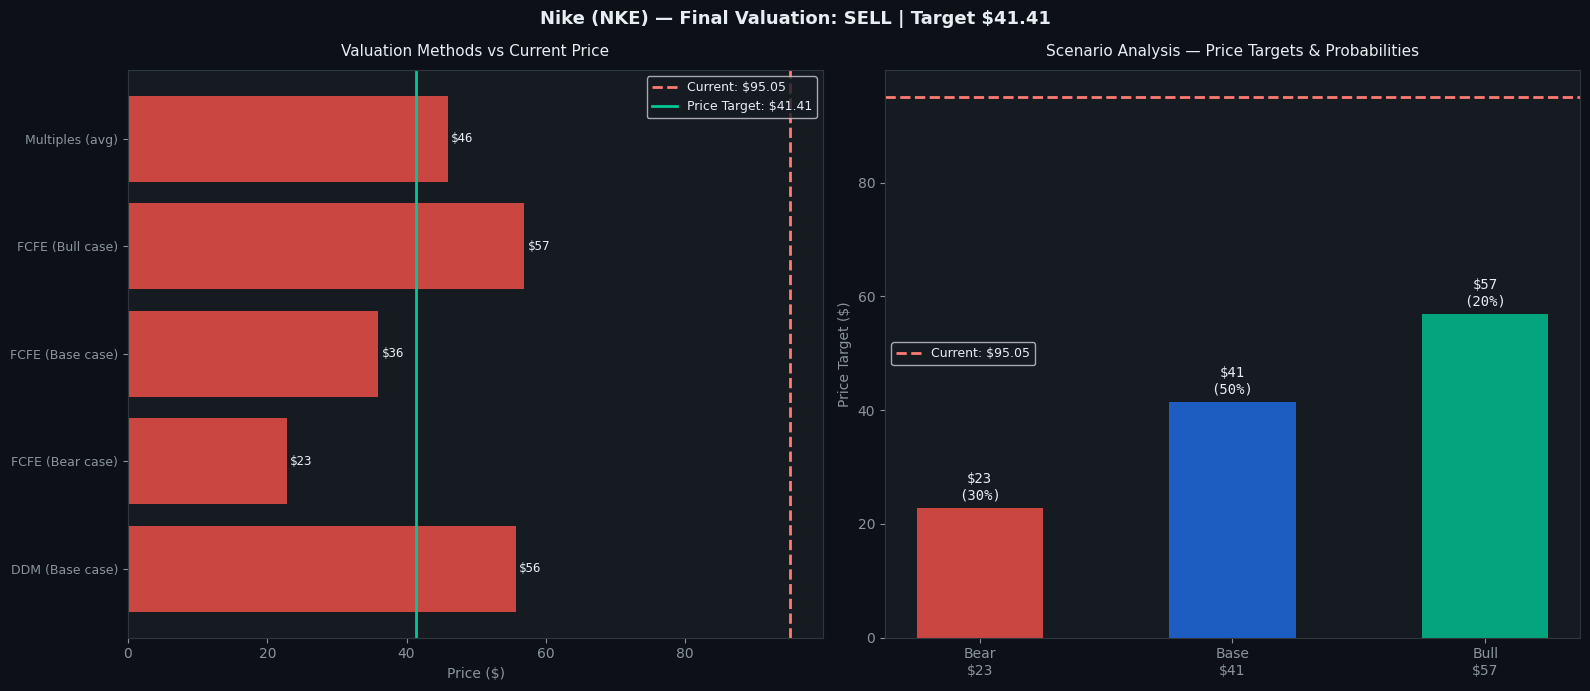

This is a teaching exercise. Not financial advice.


In [17]:
# =============================================================================
# CELL 17 — Valuation Summary & Investment Recommendation
# =============================================================================

print(f"{'='*65}")
print("NIKE (NKE) — VALUATION SUMMARY & INVESTMENT RECOMMENDATION")
print(f"{'='*65}")

# ── PRICE TARGETS FROM EACH METHOD ───────────────────────────────────────────
valuation_summary = {
    "DDM (Base case)":    {"price": ddm_results["Base"],  "weight": 0.15},
    "FCFE (Bear case)":   {"price": fcfe_prices["Bear"],  "weight": 0.20},
    "FCFE (Base case)":   {"price": fcfe_prices["Base"],  "weight": 0.30},
    "FCFE (Bull case)":   {"price": fcfe_prices["Bull"],  "weight": 0.15},
    "Multiples (avg)":    {"price": avg_implied,           "weight": 0.20},
}

print(f"\n  {'Method':<25} {'Price Target':>14} {'Weight':>8} {'Weighted':>10}")
print(f"  {'-'*60}")

weighted_price = 0
for method, data in valuation_summary.items():
    contribution = data["price"] * data["weight"]
    weighted_price += contribution
    print(f"  {method:<25} ${data['price']:>13.2f} {data['weight']:>8.0%} "
          f"${contribution:>9.2f}")

print(f"  {'─'*60}")
print(f"  {'Weighted Price Target':<25} {'':>14} {'100%':>8} "
      f"${weighted_price:>9.2f}")

print(f"\n  Current market price:  ${current_price:.2f}")
print(f"  Weighted price target: ${weighted_price:.2f}")
print(f"  Implied upside/downside: {weighted_price/current_price-1:+.2%}")

# ── RECOMMENDATION ────────────────────────────────────────────────────────────
if weighted_price > current_price * 1.15:
    rec = "BUY"
    rec_color = "✓"
elif weighted_price < current_price * 0.85:
    rec = "SELL"
    rec_color = "✗"
else:
    rec = "HOLD"
    rec_color = "→"

print(f"\n  {'='*55}")
print(f"  RECOMMENDATION: {rec} {rec_color}")
print(f"  {'='*55}")

print(f"""
  INVESTMENT THESIS

  BEAR CASE (30% probability)
  Nike's margin compression continues. The direct-to-consumer
  pivot stalls. Revenue declines in FY2026. FCF drops below
  $2B. Stock falls to $25-35.

  BASE CASE (50% probability)
  New CEO Elliott Hill stabilises the business. Revenue growth
  returns to low single digits. Margins recover partially.
  FCF recovers to $4-5B by FY2027. Stock fair value: $40-55.

  BULL CASE (20% probability)
  Full operational turnaround. Nike regains market share from
  On Running and Hoka. DTC strategy succeeds. Margins return
  to peak levels. FCF recovers to $6B+. Stock re-rates to
  $80-100 on multiple expansion.

  PROBABILITY-WEIGHTED FAIR VALUE: ${weighted_price:.2f}

  AT $95.05, NIKE IS PRICING IN THE BULL CASE.
  The market requires a near-perfect execution of the
  turnaround to justify the current valuation.
  Risk/reward is skewed to the downside.

  RECOMMENDATION: {rec}
  Price target: ${weighted_price:.2f}
  Downside risk: ${fcfe_prices['Bear']:.2f} (bear case)
  Upside potential: ${fcfe_prices['Bull']:.2f} (bull case)
""")

# ── FINAL VISUALISATION ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#0D1117')

# Panel 1 — Valuation bridge
ax1 = axes[0]
methods = list(valuation_summary.keys())
prices  = [v["price"] for v in valuation_summary.values()]
colors  = ['#F85149' if p < current_price else '#00C896' for p in prices]

bars = ax1.barh(methods, prices, color=colors, alpha=0.8)
ax1.axvline(current_price, color='#FF7B72', linewidth=2,
            linestyle='--', label=f'Current: ${current_price:.2f}')
ax1.axvline(weighted_price, color='#00C896', linewidth=2,
            linestyle='-', label=f'Price Target: ${weighted_price:.2f}')

for bar, price in zip(bars, prices):
    ax1.text(price + 0.5, bar.get_y() + bar.get_height()/2,
             f'${price:.0f}', va='center', color='#E6EDF3',
             fontsize=9, fontfamily='monospace')

ax1.set_title('Valuation Methods vs Current Price',
              color='#E6EDF3', fontsize=11, pad=10)
ax1.set_xlabel('Price ($)', color='#8B949E')
ax1.set_facecolor('#161B22')
ax1.legend(fontsize=9, facecolor='#161B22', labelcolor='#E6EDF3')
ax1.tick_params(axis='y', labelsize=9)
for spine in ax1.spines.values():
    spine.set_edgecolor('#30363D')

# Panel 2 — Scenario distribution
ax2 = axes[1]
scenario_prices = [fcfe_prices["Bear"], weighted_price, fcfe_prices["Bull"]]
scenario_labels = ["Bear\n$23", f"Base\n${weighted_price:.0f}", "Bull\n$57"]
scenario_probs  = [0.30, 0.50, 0.20]
scenario_colors = ['#F85149', '#1F6FEB', '#00C896']

bars2 = ax2.bar(scenario_labels, scenario_prices,
                color=scenario_colors, alpha=0.8, width=0.5)
ax2.axhline(current_price, color='#FF7B72', linewidth=2,
            linestyle='--', label=f'Current: ${current_price:.2f}')

for bar, price, prob in zip(bars2, scenario_prices, scenario_probs):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f'${price:.0f}\n({prob:.0%})',
             ha='center', va='bottom',
             color='#E6EDF3', fontsize=10, fontfamily='monospace')

ax2.set_title('Scenario Analysis — Price Targets & Probabilities',
              color='#E6EDF3', fontsize=11, pad=10)
ax2.set_ylabel('Price Target ($)', color='#8B949E')
ax2.set_facecolor('#161B22')
ax2.legend(fontsize=9, facecolor='#161B22', labelcolor='#E6EDF3')
for spine in ax2.spines.values():
    spine.set_edgecolor('#30363D')

fig.suptitle(f'Nike (NKE) — Final Valuation: {rec} | Target ${weighted_price:.2f}',
             color='#E6EDF3', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('nke_valuation_summary.png', dpi=150, bbox_inches='tight',
            facecolor='#0D1117')
plt.show()

print(f"{'='*65}")
print("This is a teaching exercise. Not financial advice.")
print(f"{'='*65}")

## 8. Key Takeaways

---

### What you built in this notebook

You started with a PM asking "is the selloff overdone?"
and delivered a complete equity valuation with a
defensible price target and investment recommendation.

| Method | Price Target | Weight |
|--------|-------------|--------|
| DDM (Base case) | $55.68 | 15% |
| FCFE (Bear case) | $22.80 | 20% |
| FCFE (Base case) | $35.90 | 30% |
| FCFE (Bull case) | $56.91 | 15% |
| Multiples (avg) | $45.92 | 20% |
| **Weighted Target** | **$41.41** | **SELL** |

---

### The three things to remember

**1. Always start with the business, not the model.**
Before running a single formula, we established that Nike's
problems are business-specific — not market-wide.
Revenue near flat, margins compressing, FCF cut in half.
A model built on false assumptions produces false answers.

**2. No single valuation model is sufficient.**
DDM broke down when g approached r.
FCFE depends heavily on terminal growth assumptions.
Multiples depend on which peers you choose.
Triangulating across three methods gives you conviction —
or tells you the uncertainty is too high to act.

**3. The market price is an opinion, not a fact.**
At $95, the market is pricing in a near-perfect turnaround.
Our analysis says fair value is $41.
One of us is wrong.
The job of a fundamental analyst is to have a
differentiated, well-reasoned view — and be willing
to act on it when the market disagrees.

---

### CFA Exam connection

| CFA Concept | Applied in this notebook |
|-------------|------------------------|
| Dividend Discount Model | Nike Gordon Growth Model |
| Free Cash Flow to Equity | 5-year DCF with terminal value |
| Price multiples | P/E, P/S, P/B, EV/EBITDA vs peers |
| Cost of equity (CAPM) | Rf + β × ERP |
| Scenario analysis | Bear / Base / Bull cases |

---

### Disclaimer

*This notebook is a teaching exercise built for
cfainpython.com. It is not financial advice.
Do your own research before making investment decisions.*

---

*All notebooks are free. Always.*